# Factor-Based Equity Allocation Using Risk-Adjusted Growth Signals

### Author

K.Aakanksh Reddy

### Objective

Develop a systematic equity allocation framework that identifies high-quality compounders using only historical information and evaluate its performance against an equal-weight benchmark.

### Key Features

- Fully out-of-sample backtesting
- No look-ahead bias
- Rolling 252-day training window
- 21-day rebalancing interval
- Top-15 stock selection
- Inverse-volatility weighting
- Sharpe² × CAGR factor model

# Problem Statement

Most portfolio construction approaches fall into two categories:

1. Equal-weight investing, which treats all companies identically.
2. Prediction-based models, which attempt to forecast future returns.

This project explores an alternative approach.

Instead of predicting prices, stocks are ranked using historically observed quality and growth characteristics.

The hypothesis is that companies exhibiting strong risk-adjusted performance and sustainable compounding behavior will continue to outperform a broad equal-weight portfolio over long horizons.

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize

In [124]:
stocks =   [

# Financials
'HDFCBANK.NS',
'ICICIBANK.NS',
'SBIN.NS',
'KOTAKBANK.NS',
'AXISBANK.NS',
'BAJFINANCE.NS',
'INDUSINDBK.NS',
'PFC.NS',
'RECLTD.NS',

# IT
'TCS.NS',
'INFY.NS',
'HCLTECH.NS',
'WIPRO.NS',
'TECHM.NS',

# Industrials
'SIEMENS.NS',
'ABB.NS',
'CUMMINSIND.NS',
'AIAENG.NS',

# Capital Goods
'LT.NS',
'BEL.NS',
'BHEL.NS',

# Consumer
'HINDUNILVR.NS',
'ITC.NS',
'NESTLEIND.NS',
'BRITANNIA.NS',
'TATACONSUM.NS',
'DABUR.NS',
'GODREJCP.NS',
'COLPAL.NS',
'MARICO.NS',

# Retail
'TITAN.NS',

# Pharma
'SUNPHARMA.NS',
'DIVISLAB.NS',
'CIPLA.NS',
'DRREDDY.NS',
'LUPIN.NS',

# Auto
'MARUTI.NS',
'M&M.NS',
'BAJAJ-AUTO.NS',
'EICHERMOT.NS',
'ASHOKLEY.NS',

# Materials
'ASIANPAINT.NS',
'PIDILITIND.NS',
'BERGEPAINT.NS',
'ULTRACEMCO.NS',
'SHREECEM.NS',

# Energy
'RELIANCE.NS',
'ONGC.NS',
'COALINDIA.NS',
'POWERGRID.NS',
'NTPC.NS',

# Metals
'TATASTEEL.NS',
'JSWSTEEL.NS',
'HINDALCO.NS',
'NMDC.NS',

# Telecom
'BHARTIARTL.NS',

# Healthcare
'APOLLOHOSP.NS'
]
data = yf.download(stocks, start='2010-01-01', end='2024-01-01')['Close']

data = data.dropna(axis=1, how='all')

print(f"\nValid Stocks: {len(data.columns)}")
print(list(data.columns))

[*********************100%***********************]  57 of 57 completed


Valid Stocks: 57
['ABB.NS', 'AIAENG.NS', 'APOLLOHOSP.NS', 'ASHOKLEY.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BEL.NS', 'BERGEPAINT.NS', 'BHARTIARTL.NS', 'BHEL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'COLPAL.NS', 'CUMMINSIND.NS', 'DABUR.NS', 'DIVISLAB.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GODREJCP.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS', 'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'LUPIN.NS', 'M&M.NS', 'MARICO.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NMDC.NS', 'NTPC.NS', 'ONGC.NS', 'PFC.NS', 'PIDILITIND.NS', 'POWERGRID.NS', 'RECLTD.NS', 'RELIANCE.NS', 'SBIN.NS', 'SHREECEM.NS', 'SIEMENS.NS', 'SUNPHARMA.NS', 'TATACONSUM.NS', 'TATASTEEL.NS', 'TCS.NS', 'TECHM.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS']


(3242, 57)


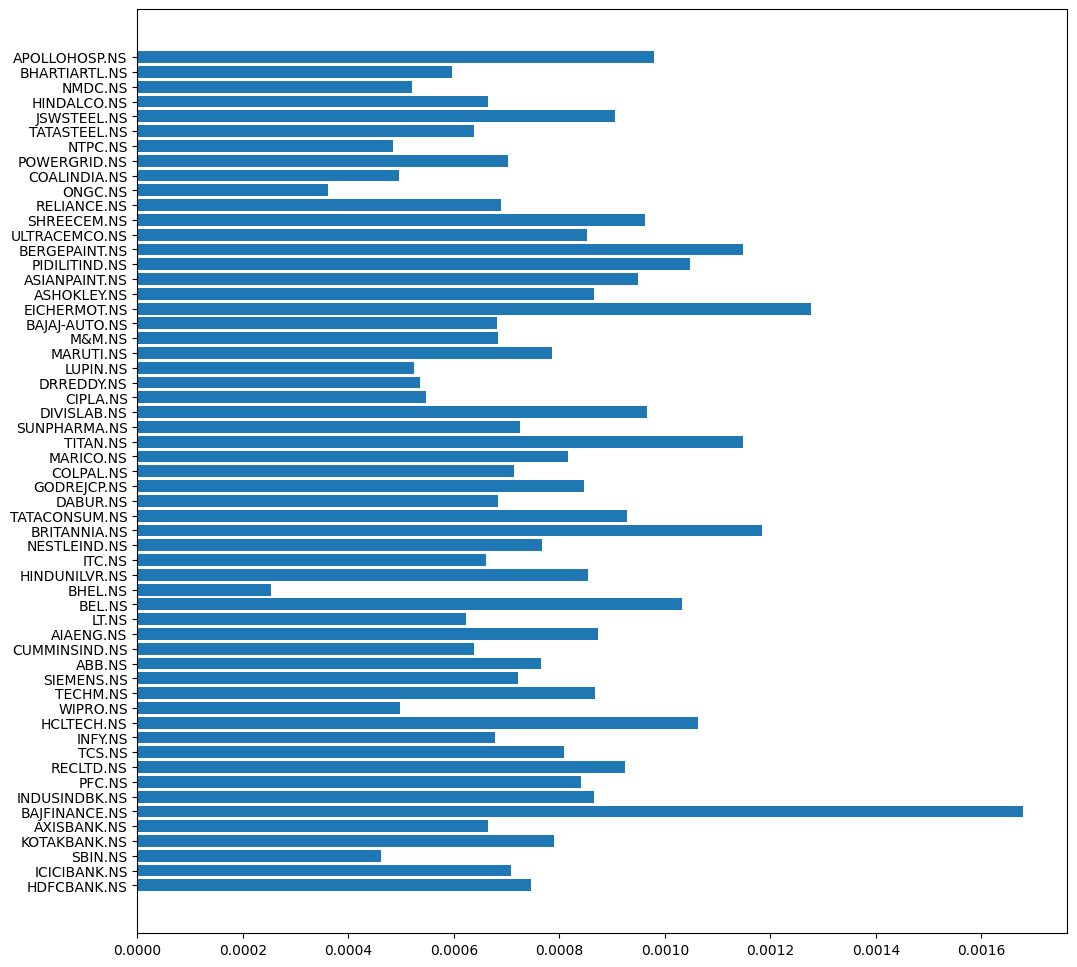

In [125]:
returns=data.pct_change().dropna()
print(returns.shape)
a=[]
for stock in stocks:
    r=np.mean(returns[stock])
    a.append(r)
plt.figure(figsize=(12,12))
plt.barh(stocks,a)
plt.show()

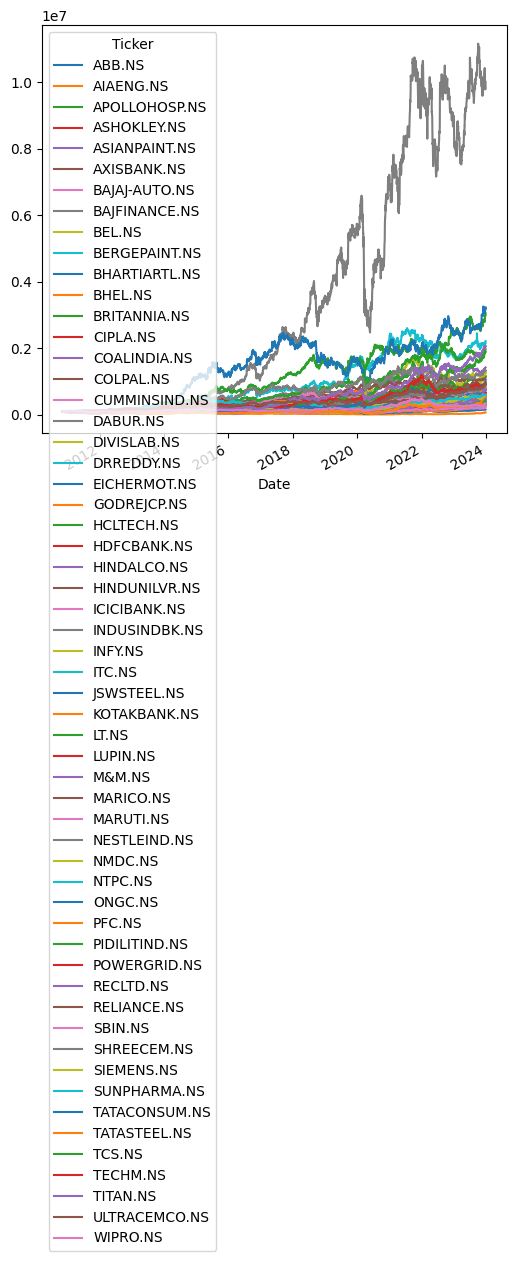

In [126]:
principal=100000
growth = (1 + returns).cumprod() * principal
growth.plot(figsize=(6,6))
plt.show()


Sharpe Ratios (Highest First)

Ticker
BAJFINANCE.NS    1.009
BRITANNIA.NS     0.934
EICHERMOT.NS     0.813
PIDILITIND.NS    0.805
HCLTECH.NS       0.743
BERGEPAINT.NS    0.734
ASIANPAINT.NS    0.702
TITAN.NS         0.695
HINDUNILVR.NS    0.660
SHREECEM.NS      0.636
DIVISLAB.NS      0.610
BEL.NS           0.581
TCS.NS           0.577
NESTLEIND.NS     0.573
ULTRACEMCO.NS    0.569
MARICO.NS        0.566
APOLLOHOSP.NS    0.561
HDFCBANK.NS      0.546
TATACONSUM.NS    0.542
COLPAL.NS        0.541
TECHM.NS         0.525
AIAENG.NS        0.519
GODREJCP.NS      0.503
KOTAKBANK.NS     0.499
POWERGRID.NS     0.488
MARUTI.NS        0.482
DABUR.NS         0.469
JSWSTEEL.NS      0.450
RECLTD.NS        0.441
BAJAJ-AUTO.NS    0.439
ITC.NS           0.425
SUNPHARMA.NS     0.424
ABB.NS           0.416
RELIANCE.NS      0.408
SIEMENS.NS       0.401
INDUSINDBK.NS    0.401
INFY.NS          0.399
ASHOKLEY.NS      0.394
PFC.NS           0.374
M&M.NS           0.374
ICICIBANK.NS     0.364
CUMMINSIND.NS    0

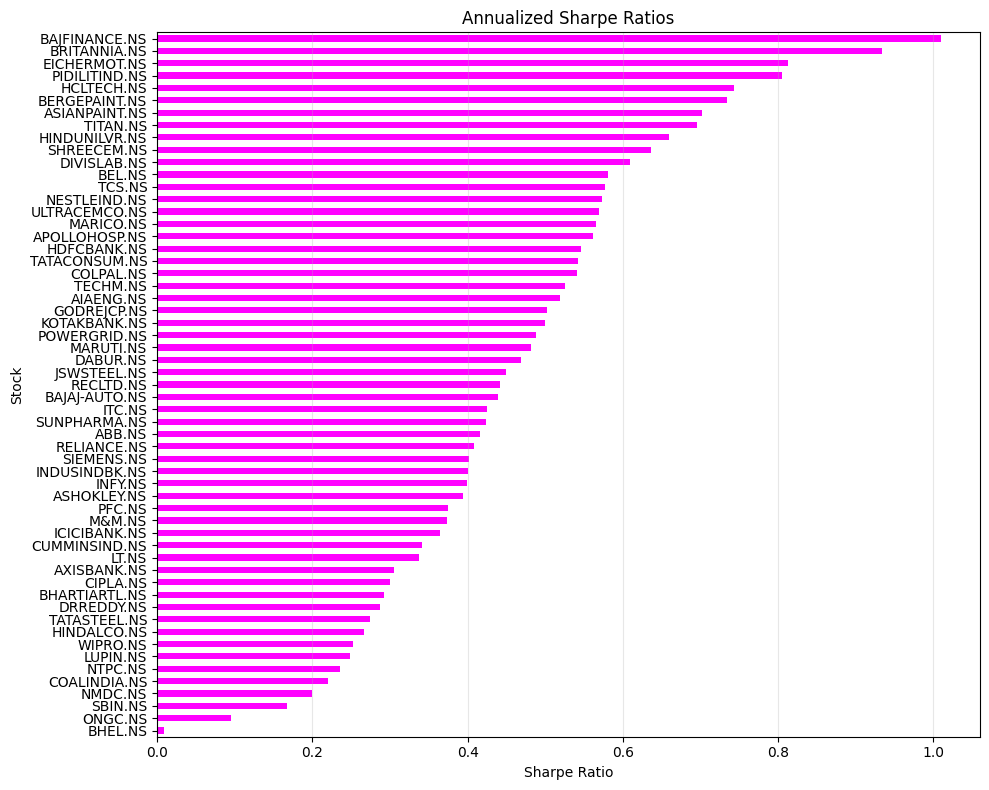

In [127]:
def sharpe(returns, risk_free_rate=0.06):
    
    excess_returns = returns - (risk_free_rate / 252)

    annual_excess_return = (
        excess_returns.mean() * 252
    )

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe_ratios = (
        annual_excess_return /
        annual_volatility.replace(0, np.nan)
    )

    return sharpe_ratios


sharpes = sharpe(returns)

#
print("\nSharpe Ratios (Highest First)\n")
print(
    sharpes.sort_values(
        ascending=False
    ).round(3)
)


plt.figure(figsize=(10, 8))

sharpes.sort_values().plot(
    kind='barh',color='magenta'
)

plt.title("Annualized Sharpe Ratios")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Stock")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
running_max = data.cummax()
drawdown = (data - running_max) / running_max
print(drawdown.min())

Ticker
ABB.NS          -0.526374
AIAENG.NS       -0.428672
APOLLOHOSP.NS   -0.394223
ASHOKLEY.NS     -0.777663
ASIANPAINT.NS   -0.286784
AXISBANK.NS     -0.631105
BAJAJ-AUTO.NS   -0.384238
BAJFINANCE.NS   -0.624378
BEL.NS          -0.672035
BERGEPAINT.NS   -0.371350
BHARTIARTL.NS   -0.467819
BHEL.NS         -0.933128
BRITANNIA.NS    -0.376758
CIPLA.NS        -0.478965
COALINDIA.NS    -0.646492
COLPAL.NS       -0.316181
CUMMINSIND.NS   -0.736886
DABUR.NS        -0.255891
DIVISLAB.NS     -0.595430
DRREDDY.NS      -0.558871
EICHERMOT.NS    -0.606646
GODREJCP.NS     -0.542253
HCLTECH.NS      -0.347221
HDFCBANK.NS     -0.410550
HINDALCO.NS     -0.743213
HINDUNILVR.NS   -0.304558
ICICIBANK.NS    -0.515305
INDUSINDBK.NS   -0.850279
INFY.NS         -0.373627
ITC.NS          -0.552811
JSWSTEEL.NS     -0.658224
KOTAKBANK.NS    -0.364990
LT.NS           -0.545987
LUPIN.NS        -0.733887
M&M.NS          -0.722771
MARICO.NS       -0.381377
MARUTI.NS       -0.582647
NESTLEIND.NS    -0.763841
NMDC.

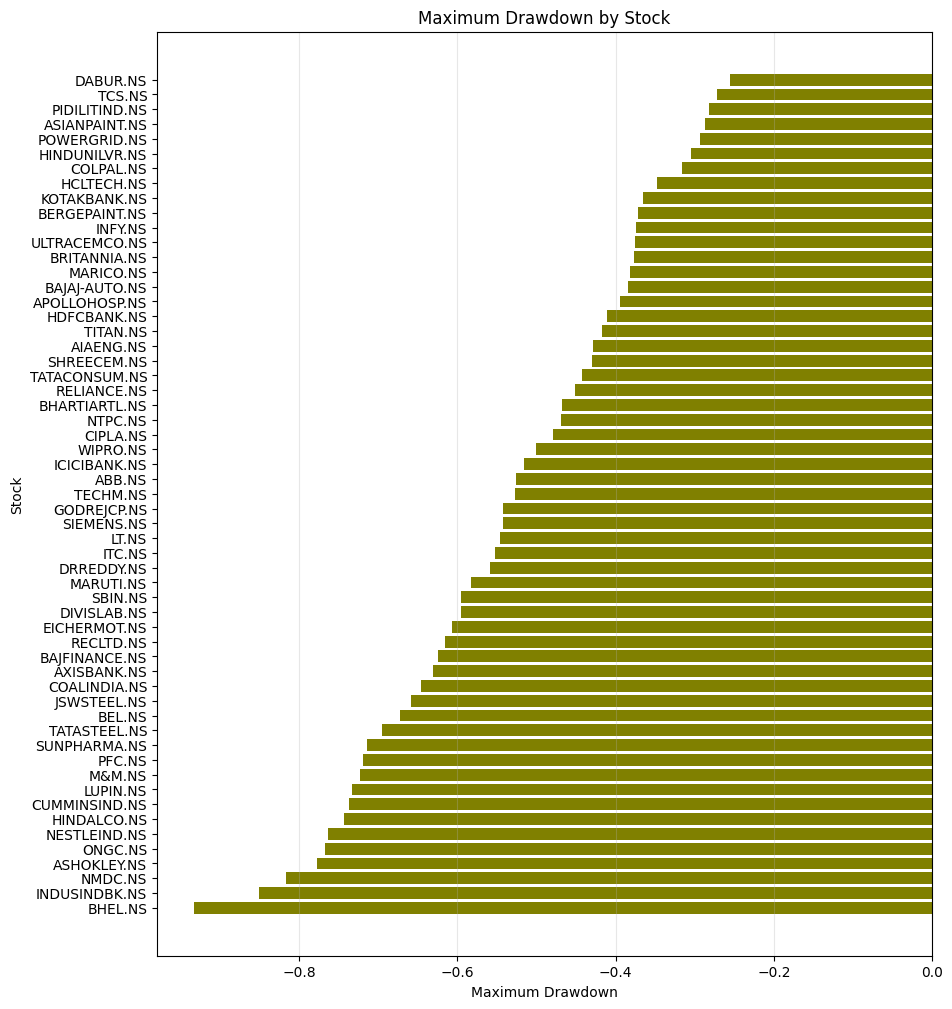

In [129]:
max_dd = drawdown.min().sort_values()

plt.figure(figsize=(10, 12))
plt.barh(max_dd.index, max_dd.values,color='olive')
plt.xlabel("Maximum Drawdown")
plt.ylabel("Stock")
plt.title("Maximum Drawdown by Stock")
plt.grid(axis='x', alpha=0.3)

plt.show()

<BarContainer object of 57 artists>

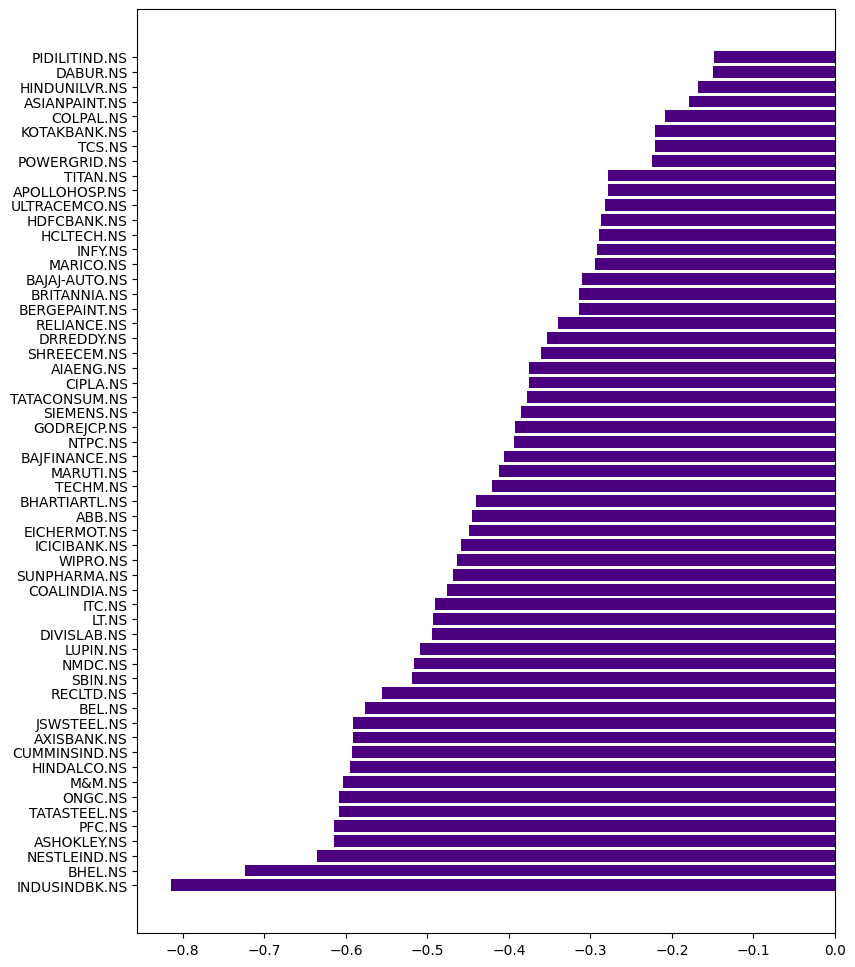

In [130]:
window = 252  
worst_declines = data.pct_change(periods=window).min()
worst_declines = pd.Series(worst_declines)
worst_declines_sorted = worst_declines.sort_values()
plt.figure(figsize=(9,12))
plt.barh(worst_declines_sorted.index, worst_declines_sorted.values,color='indigo')

# Methodology

The strategy follows a rolling walk-forward process.

For each rebalance date:

1. Use the previous 252 trading days as the training window.
2. Calculate CAGR and Sharpe ratio for every stock.
3. Compute the factor score:


Score = (Sharpe)^2 * CAGR


4. Select the Top 15 stocks.
5. Apply inverse-volatility scaling.
6. Normalize portfolio weights.
7. Hold for the next 21 trading days.
8. Repeat until the end of the dataset.

Only information available at the rebalance date is used when constructing the portfolio.

# Rolling Out-of-Sample Backtest

The strategy is evaluated using a walk-forward framework.

Training Window:
- 252 trading days

Holding Period:
- 21 trading days

Portfolio Construction:
- Sharpe² × CAGR score
- Top 15 stocks
- Inverse volatility weighting

Only historical information available at the rebalance date is used.

In [131]:
# ==============================================================================
# HISTORY-ONLY ROLLING FACTOR BACKTEST
# ==============================================================================

LOOKBACK = 252
REBALANCE = 21

portfolio_returns = []
portfolio_dates = []

weight_history = []

for i in range(LOOKBACK, len(returns)-REBALANCE, REBALANCE):

    # ==========================================================
    # TRAINING WINDOW (ONLY PAST DATA AVAILABLE)
    # ==========================================================

    train = returns.iloc[i-LOOKBACK:i]

    years = (
        (train.index[-1] - train.index[0]).days
        / 365.25
    )

    cumulative = (1 + train).cumprod()

    cagr = (
        cumulative.iloc[-1] ** (1 / years)
        - 1
    )

    annual_vol = (
        train.std()
        * np.sqrt(252)
    )

    sharpe = (
        (cagr - 0.06)
        / annual_vol.replace(0, np.nan)
    )

    sharpe_norm = (
        sharpe.clip(lower=0)
        /
        sharpe.clip(lower=0).max()
    )

    cagr_norm = (
        cagr.clip(lower=0)
        /
        cagr.clip(lower=0).max()
    )

    score = (
        sharpe_norm**2
        *
        cagr_norm
    )

    score = score.fillna(0)

    if score.sum() == 0:
        continue

    # ==========================================================
    # VOLATILITY SCALING
    # ==========================================================

    cov = train.cov() * 252

    vol = pd.Series(
        np.sqrt(np.diag(cov)),
        index=train.columns
    )

    inv_vol = 1 / vol

    top_n = 15

    selected = score.nlargest(top_n)

    raw_weights = (
        selected
        * inv_vol[selected.index]
    )

    CAP = 0.35

    weights = raw_weights / raw_weights.sum()

    while weights.max() > CAP:

        capped = weights > CAP

        excess = (
            weights[capped] - CAP
        ).sum()

        weights[capped] = CAP

        uncapped = weights < CAP

        weights[uncapped] += (
            weights[uncapped]
            / weights[uncapped].sum()
            * excess
        )

    weight_history.append(weights)

    # ==========================================================
    # FUTURE PERIOD
    # ==========================================================

    future = returns.loc[
    returns.index[i:i+REBALANCE],
    selected.index
    ]

    future_returns = future.dot(weights)

    portfolio_returns.extend(
        future_returns.values
    )

    portfolio_dates.extend(
        future_returns.index
    )

# ==============================================================================
# STRATEGY SERIES
# ==============================================================================

strategy_returns = pd.Series(
    portfolio_returns,
    index=portfolio_dates
).sort_index()


# Performance Evaluation

The strategy is compared against an equal-weight benchmark using:

- Total Return
- CAGR
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown

In [132]:
def performance_stats(daily_returns):

    years = (
        (daily_returns.index[-1]
         -
         daily_returns.index[0]).days
        / 365.25
    )

    equity = (
        1 + daily_returns
    ).cumprod()

    total_return = (
        equity.iloc[-1] - 1
    ) * 100

    cagr = (
        equity.iloc[-1] ** (1 / years)
        - 1
    )

    vol = (
        daily_returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        cagr - 0.06
    ) / vol

    drawdown = (
        equity /
        equity.cummax()
        - 1
    )

    mdd = drawdown.min()

    return pd.Series({
        "Total Return (%)": total_return,
        "CAGR (%)": cagr * 100,
        "Vol (%)": vol * 100,
        "Sharpe": sharpe,
        "Max DD (%)": mdd * 100
    })


In [133]:
equal_weights = np.ones(
    len(returns.columns)
) / len(returns.columns)

equal_returns = (
    returns.loc[
        strategy_returns.index
    ]
    .dot(equal_weights)
)


In [134]:
comparison = pd.DataFrame({
    "History-Only Strategy":
        performance_stats(strategy_returns),

    "Equal Weight":
        performance_stats(equal_returns)
    
}).T

print("\n")
print("="*100)
print("OUT-OF-SAMPLE FACTOR BACKTEST")
print("="*100)

print(
    comparison.round(2)
)




OUT-OF-SAMPLE FACTOR BACKTEST
                       Total Return (%)  CAGR (%)  Vol (%)  Sharpe  Max DD (%)
History-Only Strategy            2132.5     29.30    19.87    1.17      -35.66
Equal Weight                     1067.8     22.55    15.54    1.06      -35.16


# Growth of Capital

Comparison of ₹1 invested in:

- History-Only Strategy
- Equal Weight Benchmark

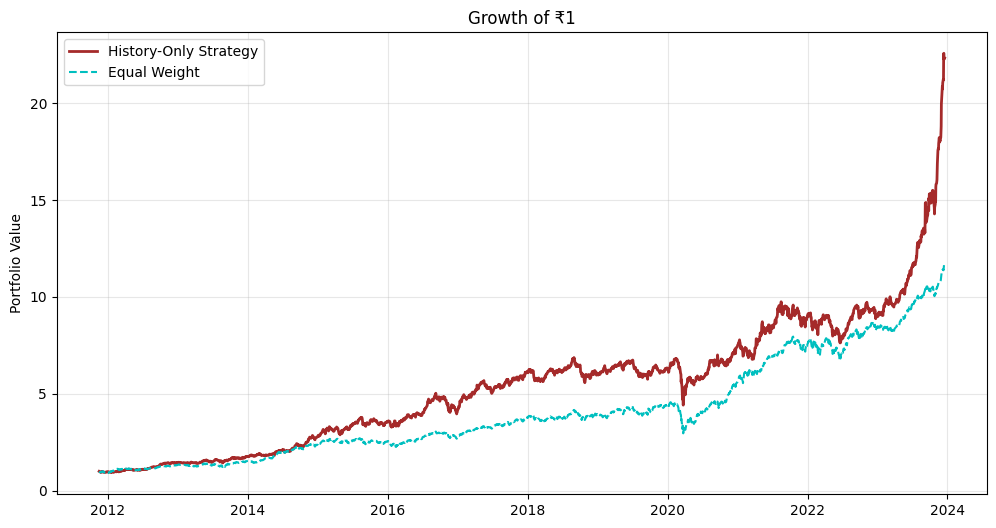

In [135]:
strategy_growth = (
    1 + strategy_returns
).cumprod()

equal_growth = (
    1 + equal_returns
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    strategy_growth,
    label="History-Only Strategy",
    linewidth=2,
    color="brown"
)

plt.plot(
    equal_growth,
    label="Equal Weight",
    linestyle="--"
    ,color='c'
)

plt.title(
    "Growth of ₹1"
)

plt.ylabel(
    "Portfolio Value"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Portfolio Characteristics

To understand what drives performance,
average portfolio weights are computed
across all rebalance periods.


Top Average Holdings



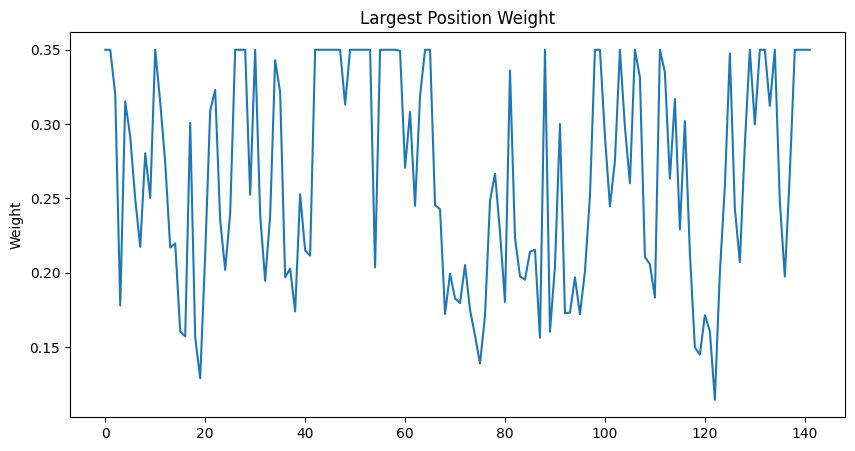

Ticker
BAJFINANCE.NS    0.069418
BRITANNIA.NS     0.052624
EICHERMOT.NS     0.048627
JSWSTEEL.NS      0.036857
ITC.NS           0.033913
DIVISLAB.NS      0.033651
SHREECEM.NS      0.031741
HINDUNILVR.NS    0.030308
BERGEPAINT.NS    0.027011
RECLTD.NS        0.025903
TATASTEEL.NS     0.025577
HCLTECH.NS       0.025355
TECHM.NS         0.024994
ASHOKLEY.NS      0.024470
NESTLEIND.NS     0.022271
dtype: float64


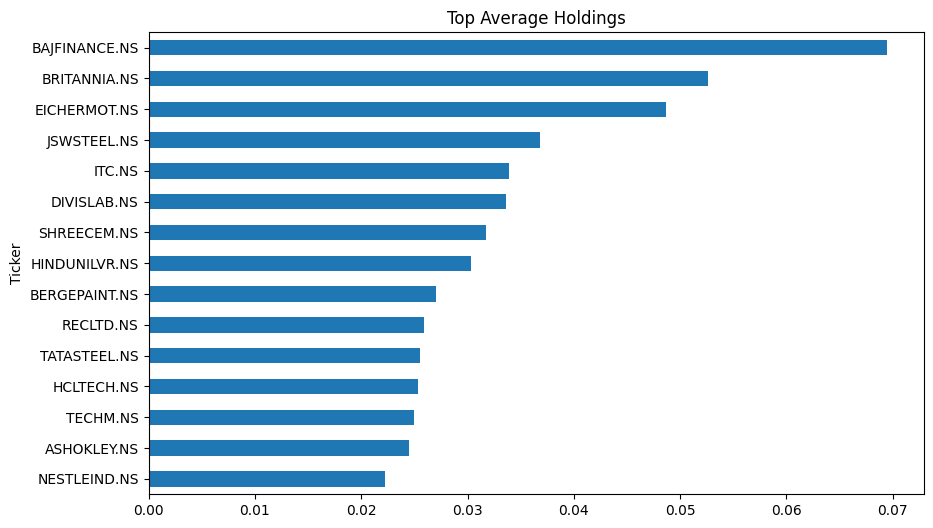

In [136]:
avg_weights = (
    pd.DataFrame(weight_history)
    .fillna(0)
    .mean()
)

print("\nTop Average Holdings\n")
concentration = []

for w in weight_history:
    concentration.append(w.max())

plt.figure(figsize=(10,5))
plt.plot(concentration)
plt.title("Largest Position Weight")
plt.ylabel("Weight")
plt.show()

print(
    avg_weights.sort_values(
        ascending=False
    ).head(15)
)
plt.figure(figsize=(10,6))

avg_weights.sort_values()\
    .tail(15)\
    .plot(kind="barh")

plt.title("Top Average Holdings")
plt.show()

[np.float64(0.35), np.float64(0.35), np.float64(0.3199148638073772), np.float64(0.17790107003239627), np.float64(0.31529231610155506), np.float64(0.29149854304553474), np.float64(0.24952487985981064), np.float64(0.2174412033757397), np.float64(0.2803816044349564), np.float64(0.2503327398214329), np.float64(0.35), np.float64(0.31461782237209934), np.float64(0.2741070588275967), np.float64(0.21692013236680593), np.float64(0.21969932261164335), np.float64(0.16041267902648818), np.float64(0.15714201514383855), np.float64(0.30084038715052436), np.float64(0.1564803025027375), np.float64(0.129039471225929), np.float64(0.2121850075423869), np.float64(0.3090094186035882), np.float64(0.3229781300517178), np.float64(0.23542560030199422), np.float64(0.2019179781872455), np.float64(0.23984990363821385), np.float64(0.35), np.float64(0.35), np.float64(0.35), np.float64(0.252443280769722), np.float64(0.35), np.float64(0.2388447114636056), np.float64(0.19464670616325522), np.float64(0.23819630233073985

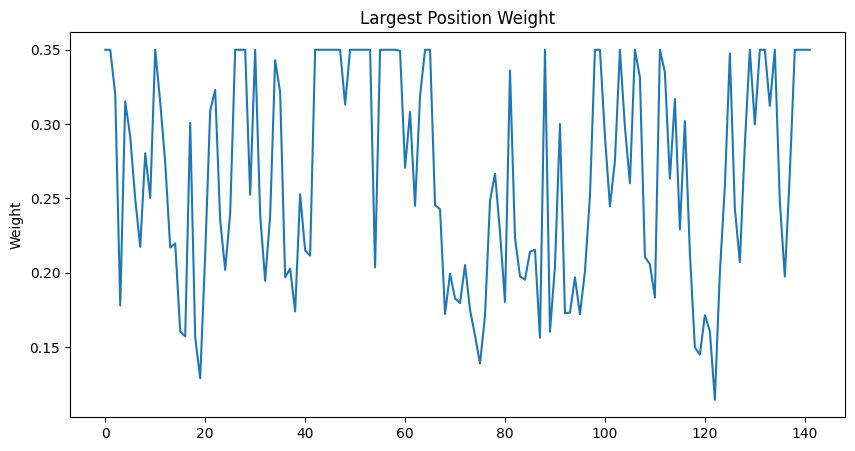

In [137]:
concentration = []

for w in weight_history:
    concentration.append(w.max())
print(concentration)

plt.figure(figsize=(10,5))
plt.plot(concentration)
plt.title("Largest Position Weight")
plt.ylabel("Weight")
plt.show()

In [138]:
for i, w in enumerate(weight_history):
    if w.max() > 0.50:
        print(i)
        print(w.sort_values(ascending=False).head())
        print()



STRATEGY vs EQUAL WEIGHT vs NIFTY 50
                       Total Return (%)  CAGR (%)  Vol (%)  Sharpe  Max DD (%)
History-Only Strategy           2132.50     29.30    19.87    1.17      -35.66
Equal Weight                    1067.80     22.55    15.54    1.06      -35.16
Nifty 50                         323.89     12.69    16.69    0.40      -38.44


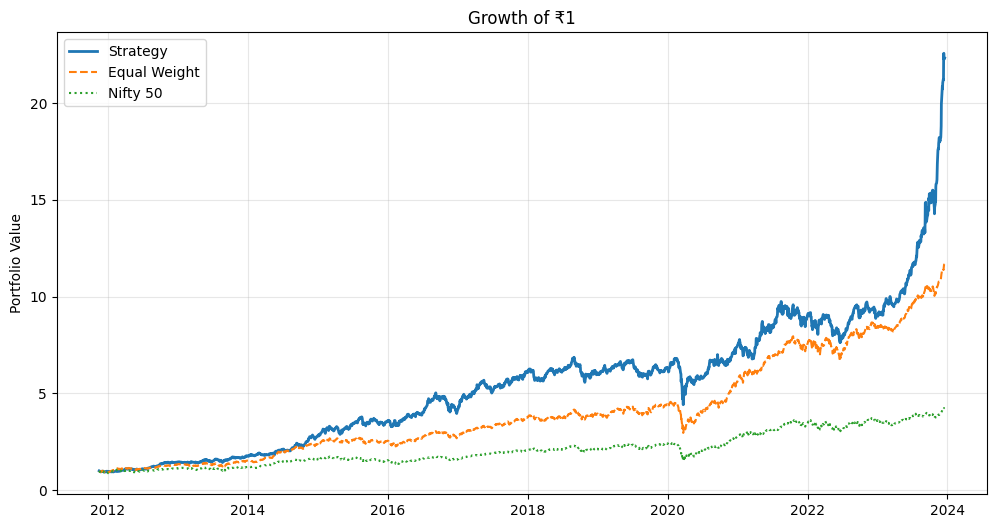

In [139]:
# ==============================================================================
# NIFTY 50 BENCHMARK
# ==============================================================================

nifty = yf.download(
    "^NSEI",
    start="2010-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

# Force Series instead of DataFrame
if isinstance(nifty, pd.DataFrame):
    nifty = nifty.squeeze()

nifty_returns = (
    nifty
    .pct_change()
    .dropna()
)

# Align benchmark with strategy period
nifty_returns = (
    nifty_returns
    .reindex(strategy_returns.index)
    .ffill()
    .fillna(0)
)
# Performance comparison
benchmark_comparison = pd.DataFrame({
    "History-Only Strategy":
        performance_stats(strategy_returns),

    "Equal Weight":
        performance_stats(equal_returns),

    "Nifty 50":
        performance_stats(nifty_returns)
}).T

print("\n")
print("="*100)
print("STRATEGY vs EQUAL WEIGHT vs NIFTY 50")
print("="*100)

print(
    benchmark_comparison.round(2)
)

# Growth curves
strategy_growth = (
    1 + strategy_returns
).cumprod()

equal_growth = (
    1 + equal_returns
).cumprod()

nifty_growth = (
    1 + nifty_returns
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    strategy_growth,
    label="Strategy",
    linewidth=2
)

plt.plot(
    equal_growth,
    label="Equal Weight",
    linestyle="--"
)

plt.plot(
    nifty_growth,
    label="Nifty 50",
    linestyle=":"
)

plt.title("Growth of ₹1")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.legend()

plt.show()